In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df=pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


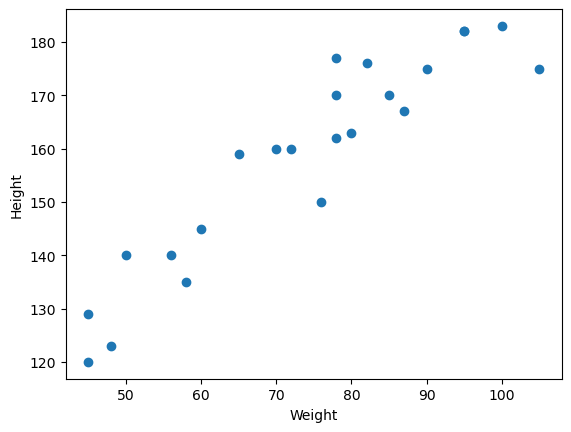

In [6]:
### Scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [7]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


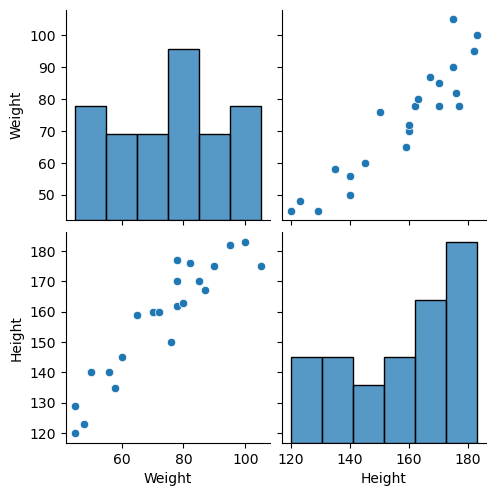

In [8]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [9]:
## Independent and dependent features

X = df.drop('Height', axis=1) ## Independent features. This should be a dataframe or 2 dimensional array

In [10]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [11]:
y = df['Height'] ## The dependent feature needs to be a series or 1 dimension
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [12]:
X.shape

(23, 1)

In [13]:
np.array(X).shape ## same as above

(23, 1)

In [14]:
y.shape

(23,)

In [15]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train.shape

(17, 1)

In [17]:
y_train.shape

(17,)

In [18]:
## Standardization
from sklearn.preprocessing import StandardScaler


In [19]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [20]:
X_test=scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [21]:
## Appliy Simple Linear regression
from sklearn.linear_model import LinearRegression

In [22]:
regression=LinearRegression(n_jobs=-1)

In [23]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [24]:
## Lets get the returned values
print('Coefficient or Slope:', regression.coef_) 
print('Intercept:', regression.intercept_)

Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


In [25]:
## Let us get the predicted values Using X_train
y_train_predict = regression.predict(X_train)
y_train_predict ## We will use this to view the model line (Best fit line)

array([141.30649667, 185.31934779, 162.26499721, 130.82724641,
       180.07972266, 127.68347133, 143.40234673, 153.88159699,
       160.16914715, 132.92309646, 139.21064662, 155.97744705,
       174.84009753, 166.45669731, 169.60047239, 171.69632245,
       164.36084726])

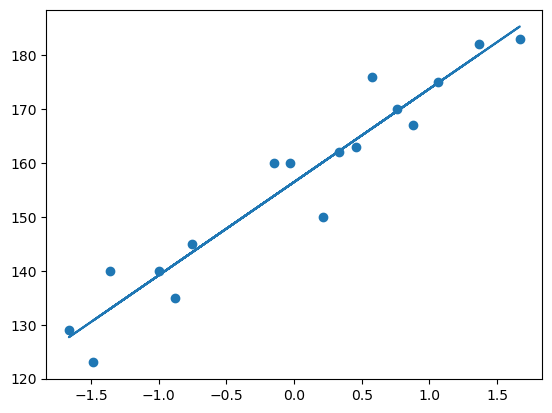

In [26]:
## Lets plot training data with the best-fit data
plt.scatter(X_train,y_train)
plt.plot(X_train, y_train_predict) ## THe best fit line

In [27]:
### Prediction Test data
# 1. predicted height outputs = intercept + coef_(Weights)
# 2. y_pred_test = 156.470 + 70.29(X_test)

In [28]:
## Predicton of test data
y_pred = regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [29]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)




Mean Squared error: 114.84069295228699
Mean Absolute error: 9.665125886795005
Root Mean Sqaured error: 10.716374991212605


In [30]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.7360826717981276


It is not very good accuracy but we will go into more advanced methods to improve this model

In [31]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.6701033397476595


In [32]:
## OLS Linear Regression (Ordinary Least Square)
import statsmodels.api as sm

In [33]:
model=sm.OLS(y_train, X_train).fit()

In [34]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 16 May 2026   Prob (F-statistic):                       0.664
Time:                        11:55:06   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [36]:
## Prediction for new data
## Lets say we want to predict the height of a person of weight 72

regression.predict([[72]]) ## remember to input with double bracket(dataframe)

array([1401.94139895])

In [37]:
## You can see that the height is not looking accurate
## This is because we standardized the training data
## Therefore we have to standardize any input

regression.predict(scaler.transform([[72]]))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

In [38]:
## This is a more correct output

### Multiple Linear Regression

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [40]:
df_index = pd.read_csv('economic_index.csv')

In [41]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [42]:
## drop unnecessary column eg year and month

df_index=df_index.drop(columns=['Unnamed: 0','year','month'],axis=1)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [43]:
## check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

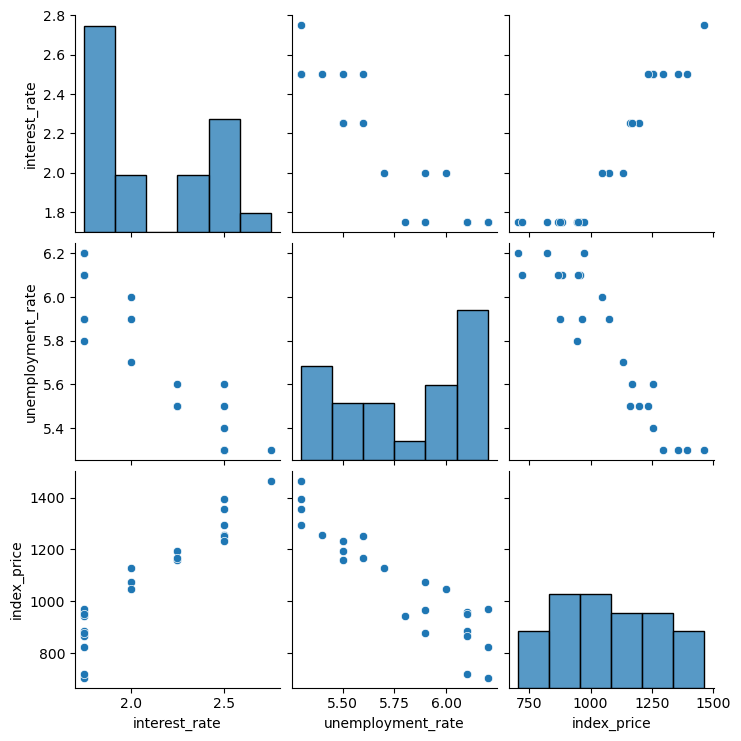

In [44]:
import seaborn as sns
sns.pairplot(data=df_index)

In [45]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

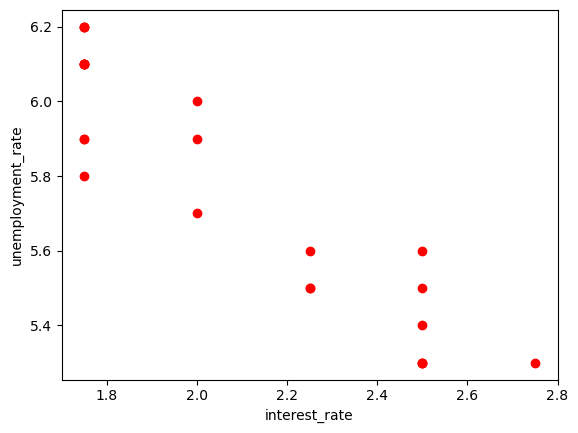

In [46]:
## Visualize the data points more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'],c='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [47]:
## Dependent and independent features (we just decided to use iloc)

X=df_index.iloc[:,:-1] ## takes all rows and all columns, except the last column
y=df_index.iloc[:,-1] ## Take the last column

In [48]:
## Elaboration

df_index.iloc[:,:-1] ## The column side is all_column - 1

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [49]:
df_index.iloc[:,-1] ## The beauty of iloc here. If you select a single column it comes as a series

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [50]:
### Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

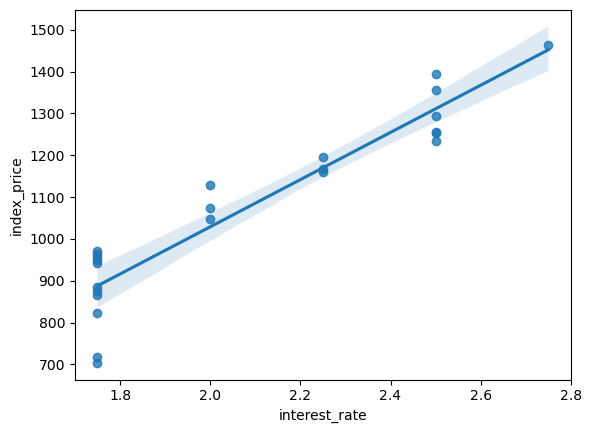

In [51]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

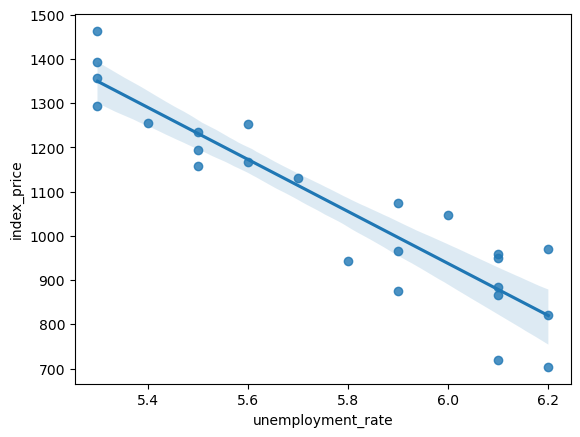

In [52]:
sns.regplot(x=df_index['unemployment_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

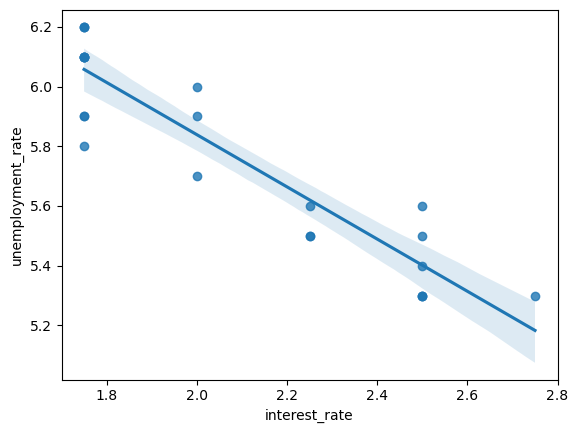

In [53]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test) ## remember not to use fit_transform for the X_test

In [55]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [56]:
regression.fit(X_train, y_train)

LinearRegression()

#### cross validation

In [57]:
## Let us try cross validation we will com back to this

from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error',cv=3)

In [58]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [59]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [60]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Mean Squared error:', mse)
print('Mean Absolute error:', mae)
print('Root Mean Sqaured error:', rmse)


Mean Squared error: 5793.762887712579
Mean Absolute error: 59.935781523235526
Root Mean Sqaured error: 76.11677139574812


In [61]:
## using r squared
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print('r square:', score)


r square: 0.8278978091457142


In [62]:
## Using Adjusted r squared

adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted r square:', adjusted_score)

Adjusted r square: 0.713163015242857


### Assumptions


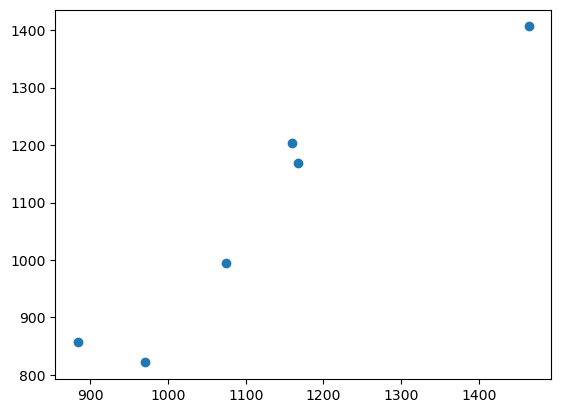

In [63]:
## 1. If there is linear relationship between the y_pred and y_test. The model performed well

plt.scatter(y_test, y_pred)

The relationship looks really good

In [64]:
## 2. We check the residuals. Then plot the kde plot. If it has a normal distribution then the model is good
residuals = y_test-y_pred
print(residuals)


8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


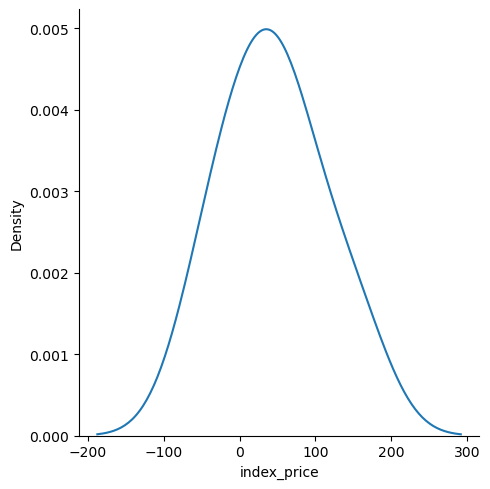

In [65]:
## plot the residuals
sns.displot(residuals,kind='kde')

The above looks really good. The residuals are normally distributed

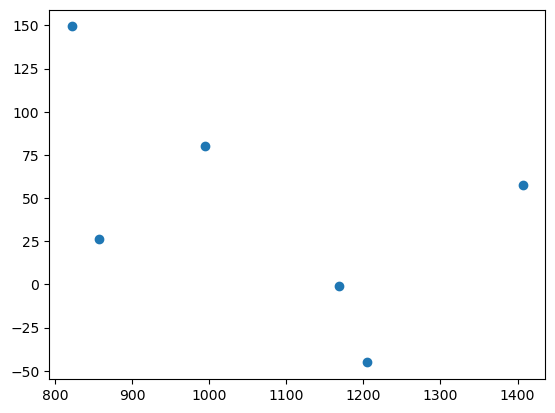

In [66]:
## 3. Create scatter plot with respect to prediction and residuals. If it is uniformly distributed (not showing any pattern) it is a good model


plt.scatter(y_pred, residuals)

The above is uniformly distributed. Therefore it is a good model

In [67]:
### OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train, X_train).fit()

In [68]:
model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 16 May 2026   Prob (F-statistic):                       0.754
Time:                        11:55:28   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
## Lets compare the coefficients between the OLS model and the Regression model

regression.coef_

array([  88.27275507, -116.25716066])

In [70]:
## We can see that the coefficients are the same

## Polynomial Regression

In [71]:
## Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [72]:
## We will create a dummy data that follows a polynomial relationship(quadratic in this case)
X1=6 * np.random.rand(100,1) - 3
y1= 0.5 * X1**2 + 1.5*X1 + 2 + np.random.randn(100,1)
## This y is the quadratic equation used
## The X_data is already scaled. No need for standard scaler


Text(0, 0.5, 'Y1 dataset')

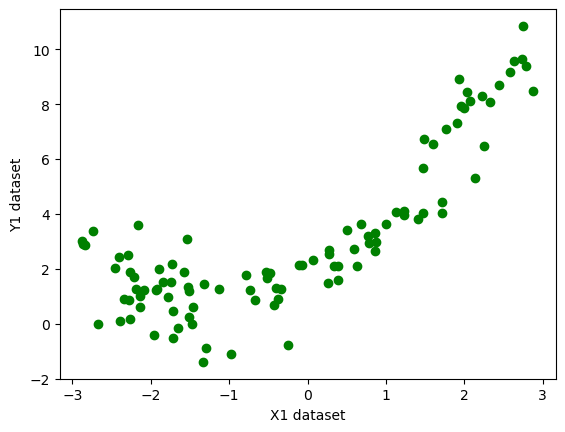

In [73]:
plt.scatter(X1,y1, color='g')
plt.xlabel('X1 dataset')
plt.ylabel('Y1 dataset')

From the plot we can see that the relationship is non linear

In [74]:
from sklearn.model_selection import train_test_split
X_train1,X_test1,y_train1,y_test1 = train_test_split(X1,y1,test_size=0.2, random_state=42)

In [75]:
## Lets implement simple linear regression
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()
regression_1.fit(X_train1, y_train1)

LinearRegression()

In [76]:
from sklearn.metrics import r2_score
score1=r2_score(y_test1, regression_1.predict(X_test1))
score1

0.1226338461097144

Text(0, 0.5, 'Y')

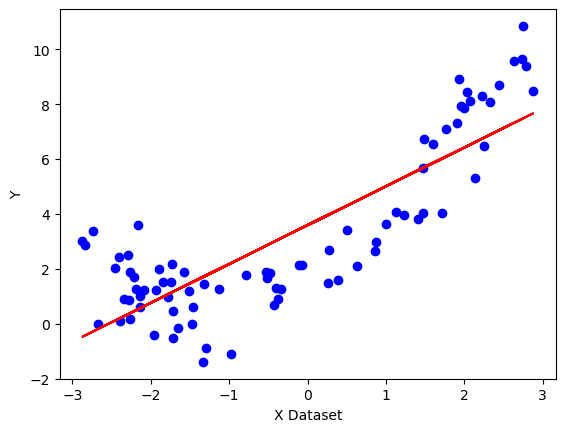

In [77]:
## Lets visualize the model
plt.plot(X_train1, regression_1.predict(X_train1), color='r')
plt.scatter(X_train1, y_train1, color='b')
plt.xlabel('X Dataset')
plt.ylabel('Y')

You can clearly see that the best fit line does not very accurately explain the data

Below we will increase the polynomial degree of the model to find the best fit that will generalize the data

In [78]:
## Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [79]:
poly=PolynomialFeatures(degree=2, include_bias=True) ## include all other terms that are below the degree 2

X_train_poly= poly.fit_transform(X_train1)
X_test_poly= poly.transform(X_test1) ## remember to use .transform() in test_data

In [80]:
X_train_poly

array([[ 1.00000000e+00, -2.66942431e+00,  7.12582615e+00],
       [ 1.00000000e+00, -2.73446356e+00,  7.47729095e+00],
       [ 1.00000000e+00,  1.40757486e+00,  1.98126699e+00],
       [ 1.00000000e+00,  2.87877494e+00,  8.28734517e+00],
       [ 1.00000000e+00,  1.59889296e+00,  2.55645870e+00],
       [ 1.00000000e+00, -2.83612320e+00,  8.04359480e+00],
       [ 1.00000000e+00, -9.71687991e-01,  9.44177552e-01],
       [ 1.00000000e+00, -1.46917746e+00,  2.15848240e+00],
       [ 1.00000000e+00, -3.38417441e-01,  1.14526364e-01],
       [ 1.00000000e+00, -1.57738331e+00,  2.48813812e+00],
       [ 1.00000000e+00,  1.76904412e+00,  3.12951710e+00],
       [ 1.00000000e+00, -2.39197190e+00,  5.72152957e+00],
       [ 1.00000000e+00,  2.13834959e+00,  4.57253896e+00],
       [ 1.00000000e+00, -2.19436509e+00,  4.81523815e+00],
       [ 1.00000000e+00, -1.72243378e+00,  2.96677813e+00],
       [ 1.00000000e+00,  1.70996874e+00,  2.92399309e+00],
       [ 1.00000000e+00, -1.13045521e+00

In [81]:
X_test_poly

array([[ 1.00000000e+00, -1.52826671e+00,  2.33559913e+00],
       [ 1.00000000e+00, -1.51289775e+00,  2.28885960e+00],
       [ 1.00000000e+00,  2.58778934e+00,  6.69665368e+00],
       [ 1.00000000e+00, -2.49549765e-01,  6.22750852e-02],
       [ 1.00000000e+00,  5.91512576e-01,  3.49887128e-01],
       [ 1.00000000e+00,  6.56676341e-02,  4.31223816e-03],
       [ 1.00000000e+00,  8.55793853e-01,  7.32383120e-01],
       [ 1.00000000e+00,  3.41116972e-01,  1.16360788e-01],
       [ 1.00000000e+00, -2.86618377e+00,  8.21500942e+00],
       [ 1.00000000e+00,  1.22994232e+00,  1.51275810e+00],
       [ 1.00000000e+00,  6.77988773e-01,  4.59668776e-01],
       [ 1.00000000e+00, -6.69191027e-01,  4.47816631e-01],
       [ 1.00000000e+00, -1.54082898e+00,  2.37415395e+00],
       [ 1.00000000e+00,  1.71842766e+00,  2.95299361e+00],
       [ 1.00000000e+00,  7.78410101e-01,  6.05922285e-01],
       [ 1.00000000e+00,  3.90183943e-01,  1.52243509e-01],
       [ 1.00000000e+00,  7.66606960e-01

We have successfully converted the x features to a higher degree of 2.

Now we can train the model with this and view the performance.

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

regression_2 = LinearRegression()
regression_2.fit(X_train_poly, y_train1)

LinearRegression()

In [83]:
y_pred1 = regression_2.predict(X_test_poly)
score2= r2_score(y_test1, y_pred1)
score2

0.8189931376716514

Notice the accuracy improved. Now lets visualize the model

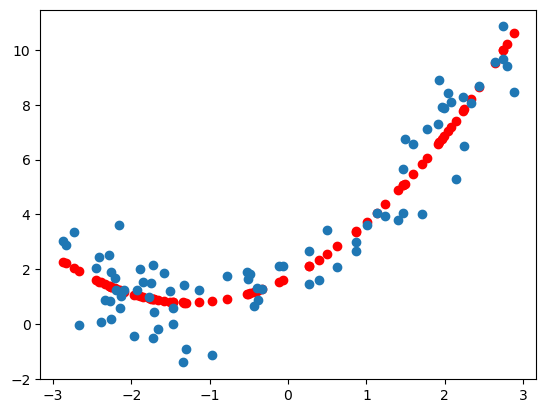

In [84]:
plt.scatter(X_train1, regression_2.predict(X_train_poly), color='red') ## We didnt use plot because it is not a straight line and can produce zig-zags
plt.scatter(X_train1, y_train1)

In [85]:
regression_2.coef_

array([[0.        , 1.44759826, 0.57461384]])

In [86]:
regression_2.intercept_

array([1.69992205])

In [87]:
## Now let us try to the highest degree of 3 to see if our model improves from 80%
poly1=PolynomialFeatures(degree=3, include_bias=True) ## include all other terms that are below the degree 2

X_train_poly3= poly1.fit_transform(X_train1)
X_test_poly3= poly1.transform(X_test1)


In [88]:
regression_3 = LinearRegression()
regression_3.fit(X_train_poly3, y_train1)

LinearRegression()

In [89]:
y_pred3 = regression_3.predict(X_test_poly3)
score3= r2_score(y_test1, y_pred3)
score3

0.801726106922138

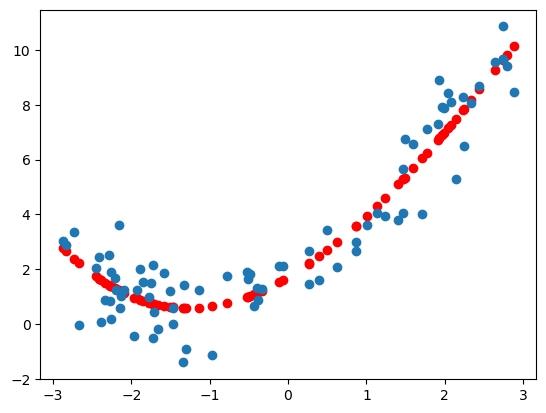

In [90]:
plt.scatter(X_train1, regression_3.predict(X_train_poly3), color='red') ## We didnt use plot because it is not a straight line and can produce zig-zags
plt.scatter(X_train1, y_train1)

Notice with a degree of 3, the accuracy dropped but not by much. from 80% to 79%. So we will continue with regression_2 model

In [91]:
## Now predicting new data
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new) ## we have to poly transform the new data so it can work with the polynomial model.
## NOTE: We used poly instead of poly3 which is the polynomial object we created for degree=2
X_new_poly


array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

You can see we transformed the new data to a higher degree of 2. If we used poly3 it would have 4 parameters because the degree is 3

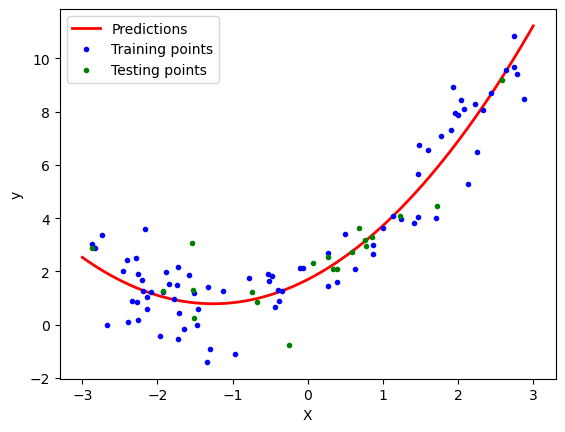

In [92]:
y_new = regression_2.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth=2, label='Predictions')
plt.plot(X_train1,y_train1,'b.', label='Training points')
plt.plot(X_test1, y_test1, 'g.', label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### PIPELINE IN POLYNOMIAL

In [93]:
## We will use pipelining concept
from sklearn.pipeline import Pipeline

def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg=LinearRegression()
    ## In the pipeline arrange according to how you want the flow to be
    ## First we want the polynomial features created 
    ## Then the regression model
    ## The names can be anything, just ensure you pass in the correct object
    poly_regression=Pipeline([
        ('poly_features',poly_features), 
        ('lin_reg',lin_reg)
    ])
    poly_regression.fit(X_train1,y_train1) ##It creates the polynomial features and then fit the regression line
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new,y_pred_new,'r',label='Degree ' + str(degree), linewidth=3)
    plt.plot(X_train1, y_train1, 'b.', linewidth=3)
    plt.plot(X_test1, y_test1, 'g.', linewidth=3)
    plt.legend(loc='upper left')
    plt.axis([-4,4,0,10])

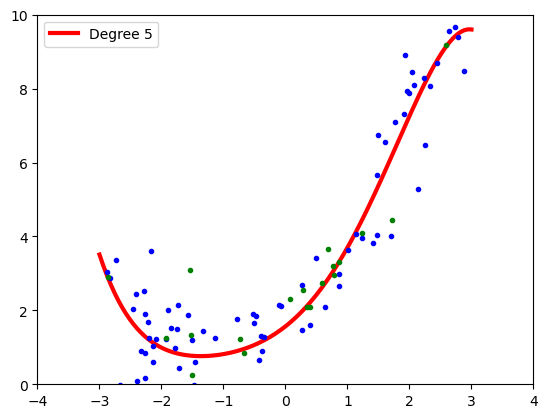

In [94]:
poly_regression(5)

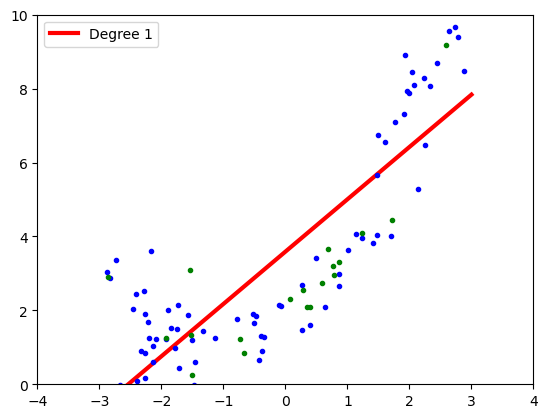

In [95]:
poly_regression(1)

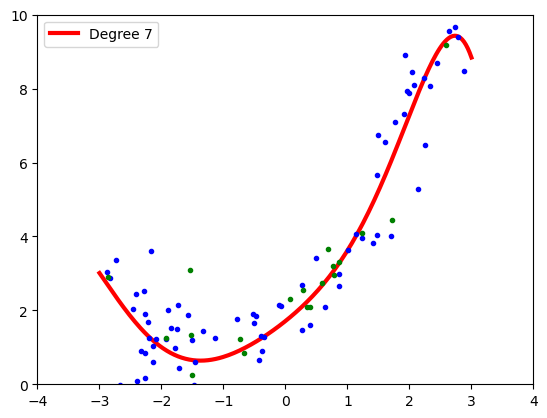

In [96]:
poly_regression(7)

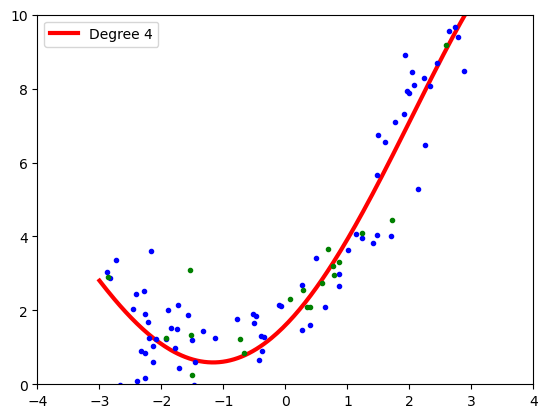

In [97]:
poly_regression(4)

# Ridge, Lasso, Elasticnet

### Algerian Forest Fires Dataset

The dataset includes 244 instances that regroup a data of two regions of Algeria, namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attributes and 1 output attribute (class)
The 244 instances have been classified into fire (138 classes) and not fire (106 classes) classes.

1. Day: The day
2. Month: The Month
3. Year: The Year 2012
4. Temperature: Temperature noon (temperature max) in Celsius degrees: 22 to 42
5. RH: Relative Humidity in %: 21 to 90
6. Ws: Wind speed in km/h: 6 to 29
7. Rain: Total day in mm: 0 to 16.8
8. FFMC: Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
9. DMC: Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
10. DC: Drought Code (DC) index from the FWI system: 7 to 220.4
11. ISI: Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
12. BUI: Buildup Index (BUI) index from the FWI system: 1.1 to 68
13. FWI: Fire Weather Index (FWI) Index: 0 to 31.1
14. Classes: two classes, namely fire and not fire.



In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [99]:
dataset = pd.read_csv('Algerian_forest_fires_dataset.csv')
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [100]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


#### Data cleaning Process 

In [101]:
## Check missing values

dataset[dataset.isnull().any(axis=1)] ## We are checking if there are null values in any column

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset is converted into two sets based on Region from 123rd index, we can make a new column based on the Region. The 122nd index is an expty row space that should be removed

1: 'Bejaia Region Dataset'
2: 'Sidi-Bel Abbes Region Dataset'

Add new column with region

In [102]:
dataset.drop(index=122, inplace=True)

In [103]:
## Check missing values again

dataset[dataset.isnull().any(axis=1)] ## We are checking if there are null values in any column

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [104]:
dataset.loc[:123,'Region']=0
dataset.loc[123:, 'Region']=1
## We needed to create a region column so we can separate the two parts of the data
## the data is divided into 2. The 'Sidi-Bel Abbes Region Dataset' is the second region

In [105]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 38.9+ KB


In [106]:

dataset[['Region']]=dataset[['Region']].astype(int)

In [107]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [108]:
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [109]:
dataset = dataset.dropna().reset_index(drop=True)
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [110]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    object
 1   month        244 non-null    object
 2   year         244 non-null    object
 3   Temperature  244 non-null    object
 4    RH          244 non-null    object
 5    Ws          244 non-null    object
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      244 non-null    object
 14  Region       244 non-null    int32 
dtypes: int32(1), object(14)
memory usage: 27.8+ KB


In [111]:
dataset.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

We have a situation where we have spaces in the column name, which will cause error. We have to remove those white spaces

In [112]:
## Fix white saces in column names
dataset.columns=dataset.columns.str.strip()
dataset.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [113]:
dataset[dataset['month'] == 'month']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [114]:
dataset = dataset.drop(index=122).reset_index(drop=True)
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [115]:
## Lets convert the required columns as Integer datatype
dataset[['month','day','year','Temperature','RH','Ws']]=dataset[['month','day','year','Temperature','RH','Ws']].astype(int)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int32 
 1   month        243 non-null    int32 
 2   year         243 non-null    int32 
 3   Temperature  243 non-null    int32 
 4   RH           243 non-null    int32 
 5   Ws           243 non-null    int32 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(7), object(8)
memory usage: 22.0+ KB


In [116]:
## changing the other columns to float datatype

objects=[features for features in dataset.columns if dataset[features].dtypes=='O']
## These are the columns with object type
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [117]:
for i in objects:
    if i!='Classes':
        dataset[i]=dataset[i].astype(float)

## this will convert all the dataset columns in the objects list except 'Classes'

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int32  
 1   month        243 non-null    int32  
 2   year         243 non-null    int32  
 3   Temperature  243 non-null    int32  
 4   RH           243 non-null    int32  
 5   Ws           243 non-null    int32  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int32  
dtypes: float64(7), int32(7), object(1)
memory usage: 22.0+ KB


In [118]:
dataset.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


### EDA and Feature Engineering

In [119]:
## let us save the cleaned dataset
dataset.to_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [120]:
## Begin exploratory data analysis(EDA)
## drop unuseful columns
df_copy = dataset.drop(columns=['day','month','year'], axis=1)

In [121]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [122]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

We can observe that the classes are of two categories but are somehow separate. We can say that there might be extra spaces in the data that we have to strip

In [123]:
df_copy['Classes']=df_copy['Classes'].str.strip()
df_copy['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [124]:
## Encode the categories of the classes
df_copy['Classes']=np.where(df_copy['Classes']=='not fire',0,1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


Another way we could have done it is using contains() method
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

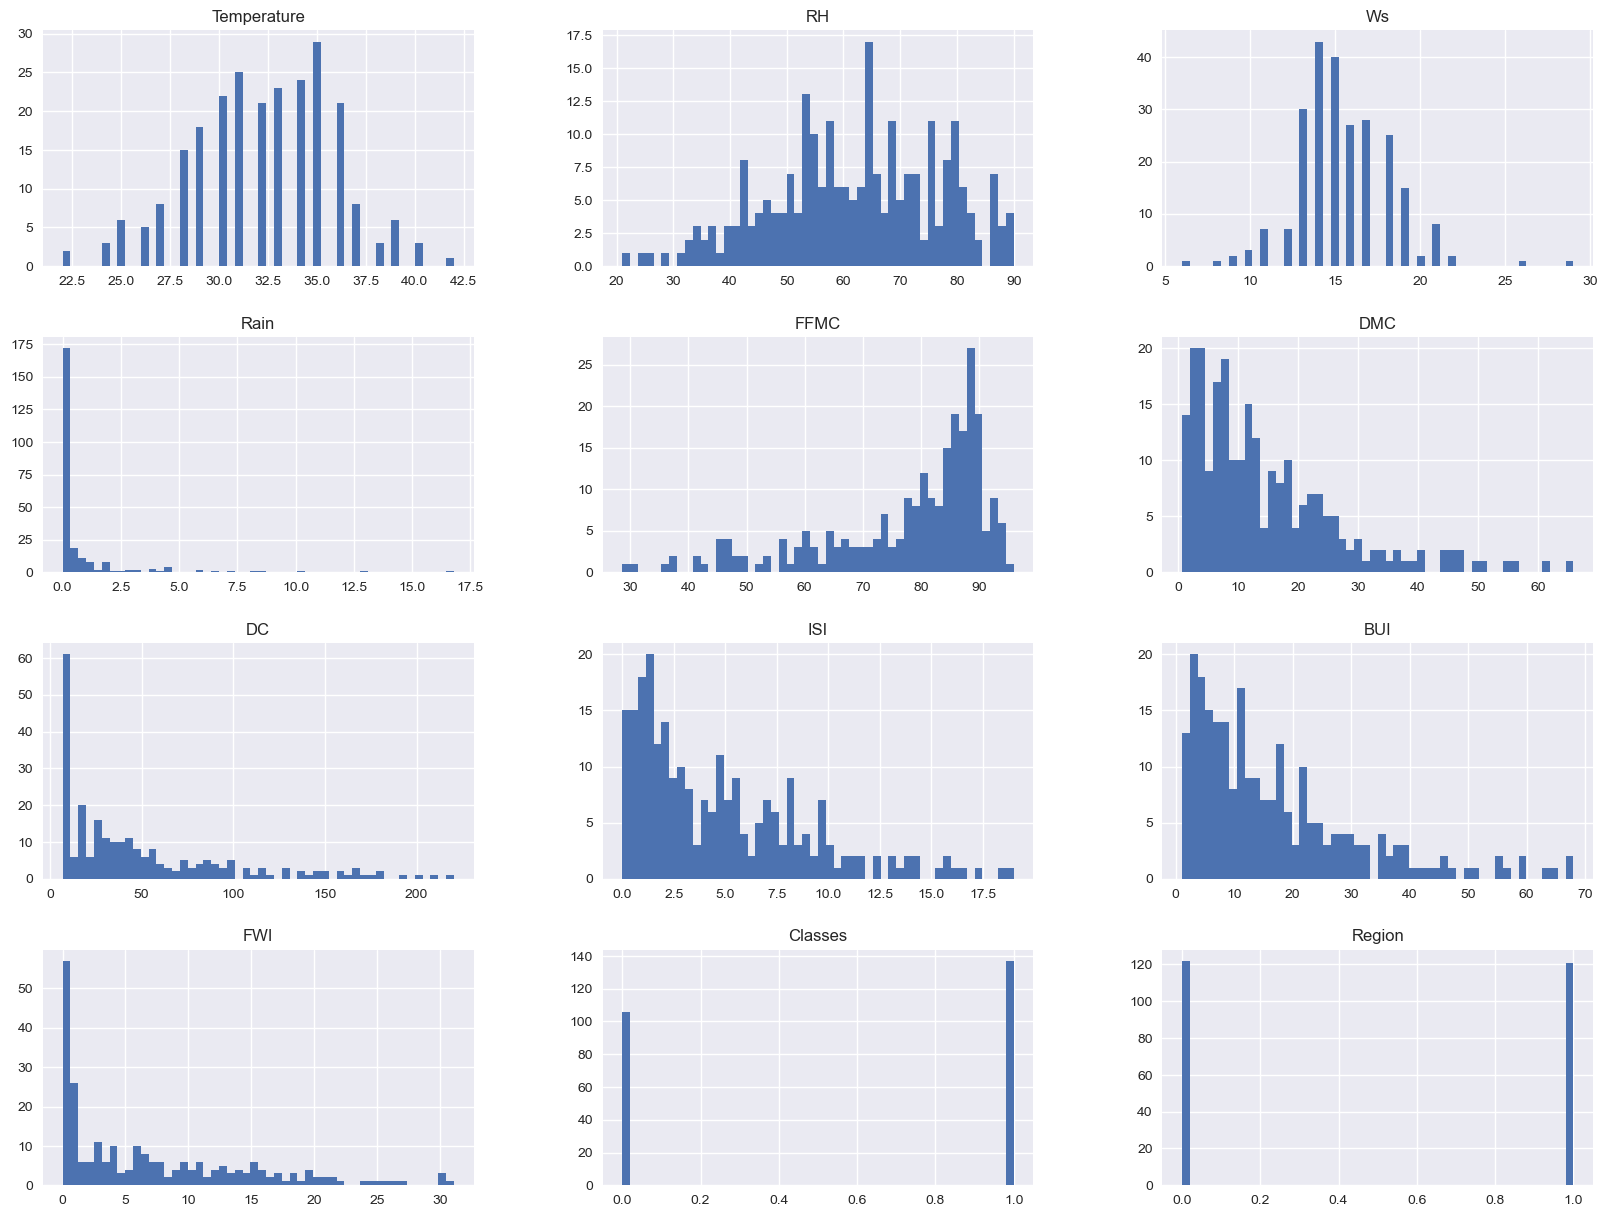

In [125]:
## Plot the density-plot for all features
plt.style.use('seaborn-v0_8') ## This will make sure it uses seaborn styling. With specified version
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [126]:
## Percentage for Pie Chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100 ## we are going to get the percentages

In [127]:
percentage=percentage.round(2)
percentage

Classes
1    56.38
0    43.62
Name: proportion, dtype: float64

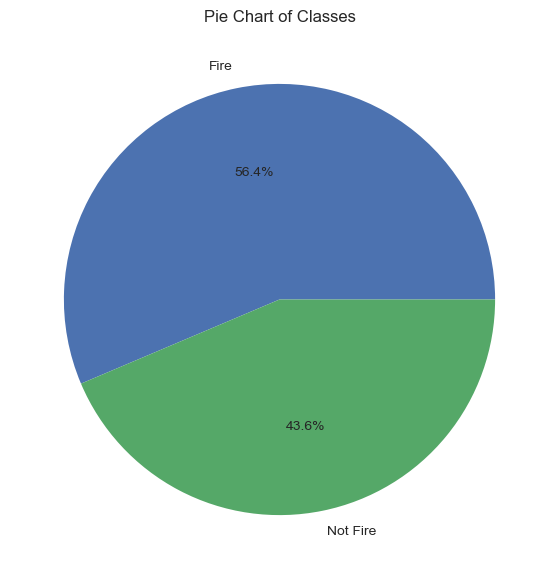

In [128]:
# plotting piechart
classlabels=['Fire','Not Fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Pie Chart of Classes')
plt.show()

In [129]:
## Correlation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

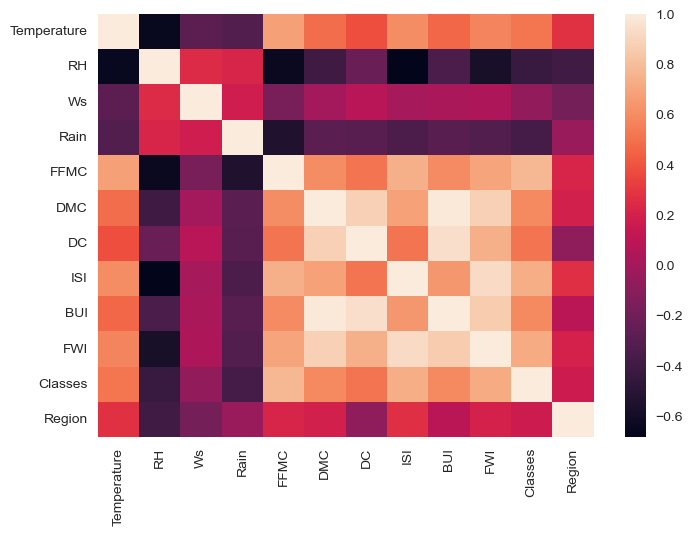

In [130]:
## The heatmap
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

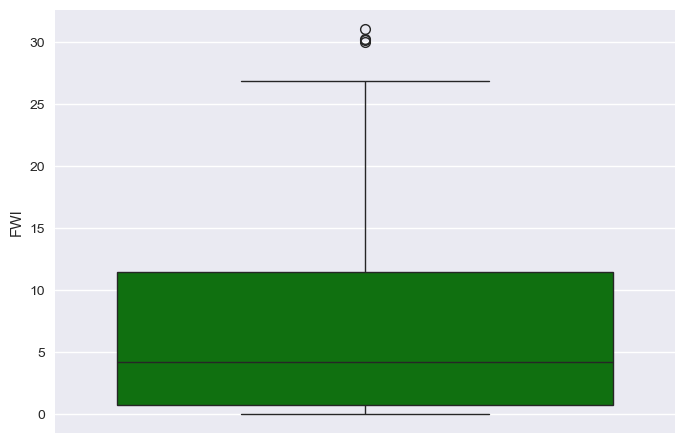

In [131]:
## Boxplots

sns.boxplot(df_copy['FWI'], color='green')

Text(0.5, 1.0, 'Fire Analysis of Sidi-Bel Regions')

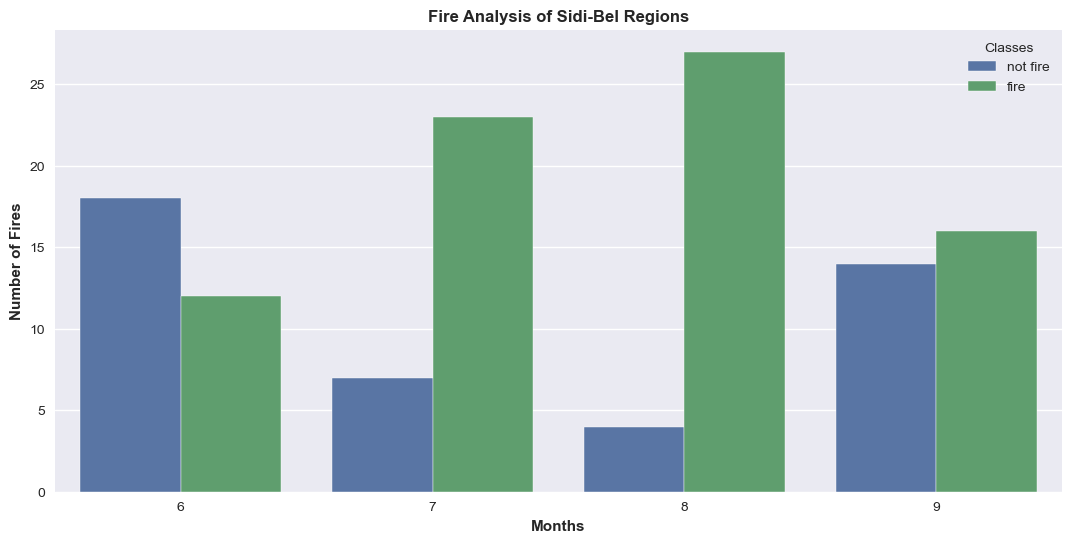

In [132]:
## Monthly Fire Analysis by Region
## We will use dataset not df_copy, because we dropped the month
dataset['Classes']=dataset['Classes'].str.strip() ## We are correcting the spacing in the column data
dftemp=dataset.loc[dataset['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dftemp)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Sidi-Bel Regions', weight='bold')

## STudy this


The highest number of fires in Sidi-Bel region occured in the month of August

Text(0.5, 1.0, 'Fire Analysis of Bejaia Regions')

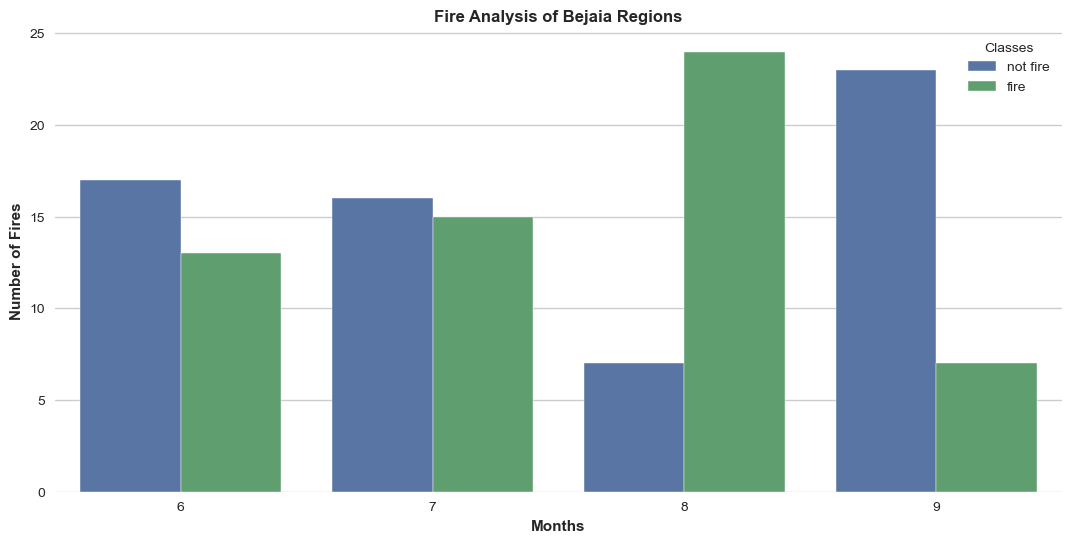

In [133]:
dftemp=dataset.loc[dataset['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dftemp)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Bejaia Regions', weight='bold')


We observe for Bejaia region, the highest month with fire is August

Text(0.5, 1.0, 'Fire Analysis per Month')

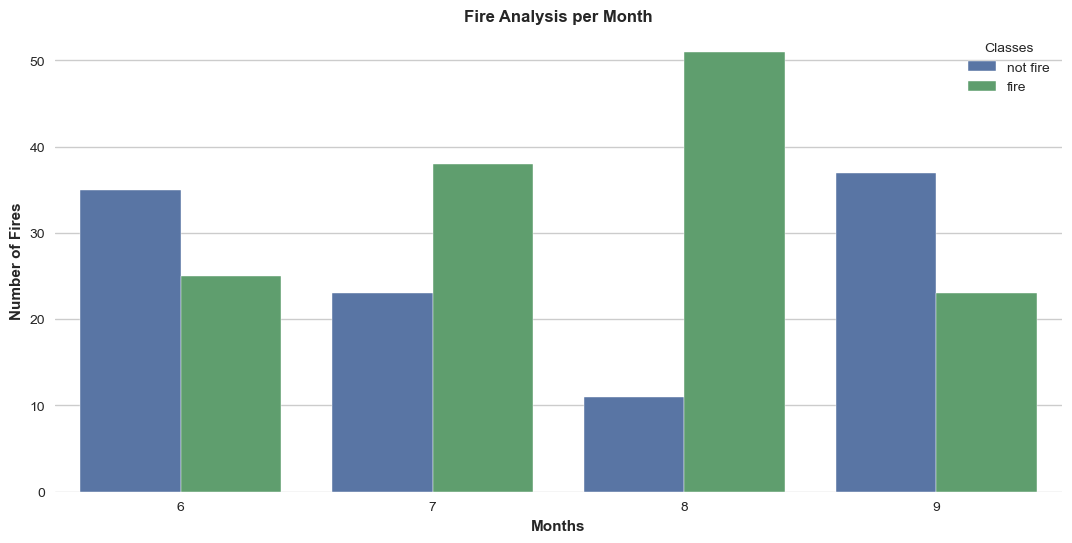

In [134]:
## In both regions combined
dftemp=dataset.loc[dataset['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dataset)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis per Month', weight='bold')


### Model Training

In this training we will use FWI as the target variable. This is because we are still learning Linear regression

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [136]:
## We will use the cleaned dataset
clean_df= pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
clean_df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [137]:
## We forgot to not include the index in the cleaned data wen we saved it. Now it is coming in as a new column
## We have to drop the unwanted column eg 'Unnamed: 0'

clean_df.drop(columns=['month','day','year'], axis=1, inplace=True)
clean_df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [138]:
clean_df.drop(columns=['Unnamed: 0'], axis=1,inplace=True)
clean_df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [139]:
clean_df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [140]:
clean_df['Classes']=np.where(clean_df['Classes'].str.contains('not fire'),0,1)
clean_df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [141]:
clean_df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [142]:
## Independent and Dependent features
X=clean_df.drop('FWI',axis=1) ## remember X has to be a dataframe
y=clean_df['FWI'] ## y has to be a series



In [143]:
## Train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [144]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [145]:
## feature selection based on correlation (This should have been done before splitting)
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

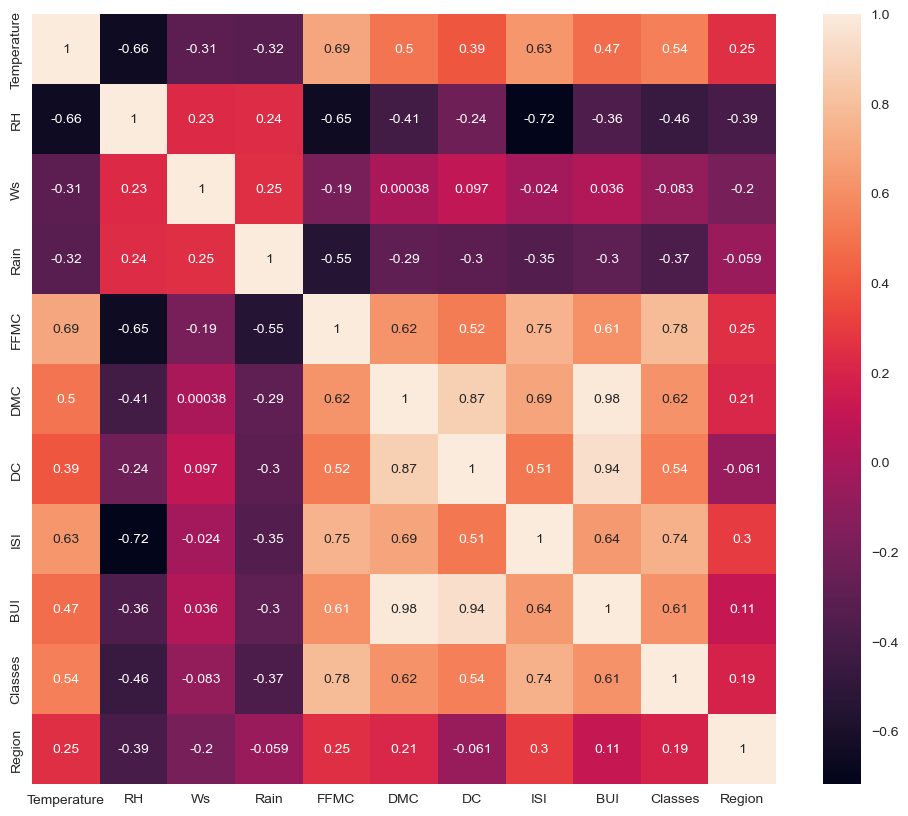

In [146]:
## check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [147]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [148]:
correlation(X_train,0.90)

{'BUI'}

If we check the correlation matrix, we can observe that the feature BUI is highly correlated with DMC(0.98) and DC(0.94). Ths is because we set the threshold at 0.9. Now we can re move BUI because DMC and DC will cover it as they have nearly the same effect.

##### NOTE: THE NORMAL THRESHOLD IS SETUP BY THE DOMAIN EXPERT/PROJECT MANAGER

In [149]:
## lets set threshold to 0.85
corr_features=correlation(X_train, 0.85)

In [150]:
## Drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape, X_test.shape

((182, 9), (61, 9))

In [151]:
## Feature scaling and Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Text(0.5, 1.0, 'X_train After Scaling')

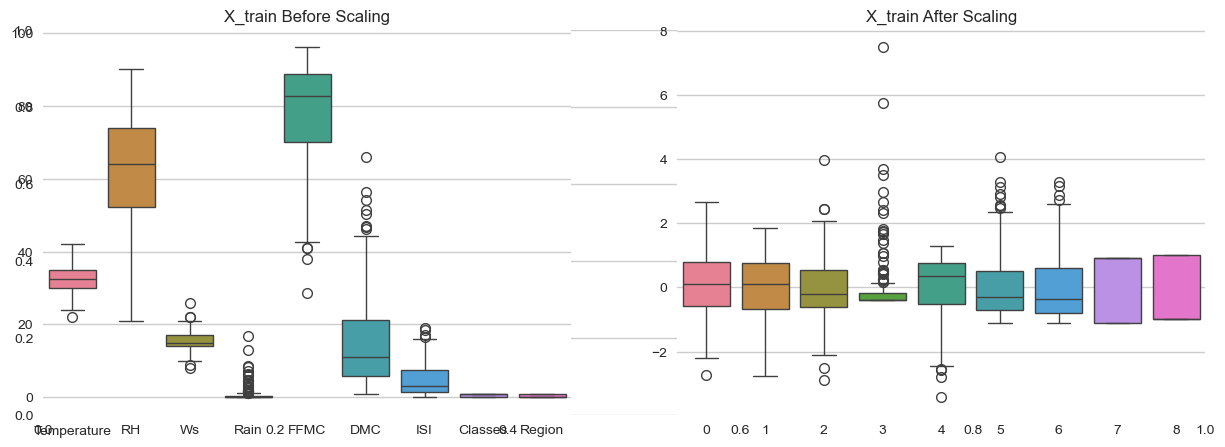

In [152]:
### Lets compare the outliers for data that is not standardized and that which is standardized
## We will use boxplot
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')


You observe in the second figure. The scale for all the features are the same. Which is very helpful

#### Linear Regression Model

In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


linreg=LinearRegression()
linreg.fit(X_train_scaled, y_train)

LinearRegression()

In [154]:
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)

Mean absolute error:  0.5468236465249976
R2 score:  0.9847657384266951


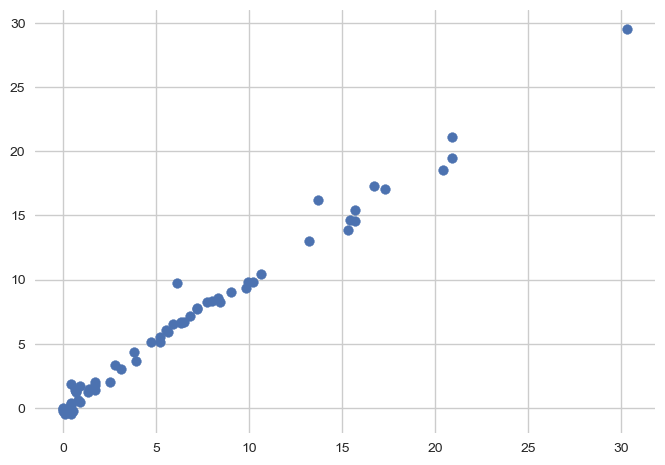

In [155]:
## Recall if the y-test and y_pred have a linear relationship then it is a good model.
## we can view it with a scatter plot
plt.scatter(y_test,y_pred)

This looks very good. 

We also have to take note that whenever we try to execute linear regression there are chances that we might be overfitting the model so here Rigde and Lasso regression come in.

#### Lasso Regression (L1 regularization for feature selection)

Mean absolute error:  1.1331759949144085
R2 score:  0.9492020263112388


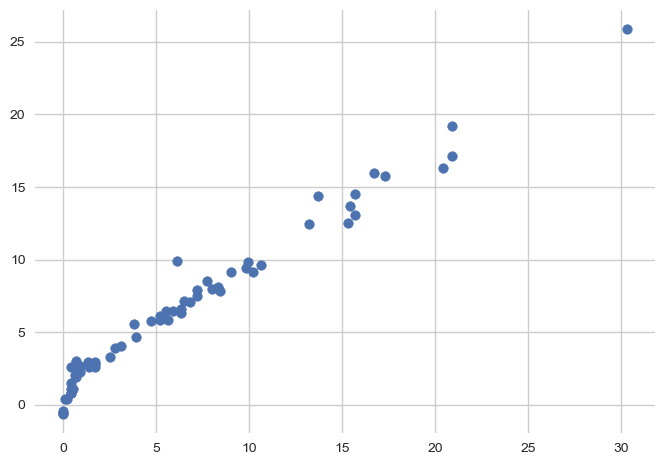

In [156]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score


lasso=Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

Notice the error increased LR error was 0.54 while Lasso error is 1.13. Normally i would say the error increased to avoid overfitting of the model but then we are using the test data to compare with the predicted data which is the real test for performance. We are not comparing with the training data. We can investigate further into this.

#### Ridge Regression (L2 regularlization to avoid Overfitting)

Mean absolute error:  0.5642305340105693
R2 score:  0.9842993364555513


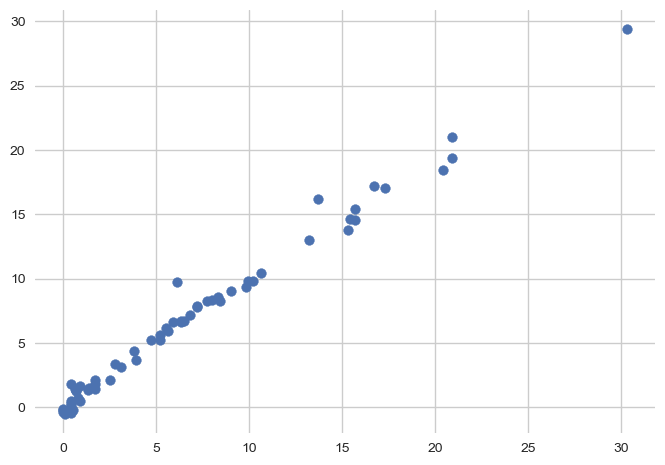

In [157]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


ridge=Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

If you want to combine both Ridge and Lasso we us Elasticnet Regression


#### Elasticnet Regression (Combines Ridge and Lasso)

Mean absolute error:  1.8822353634896
R2 score:  0.8753460589519703


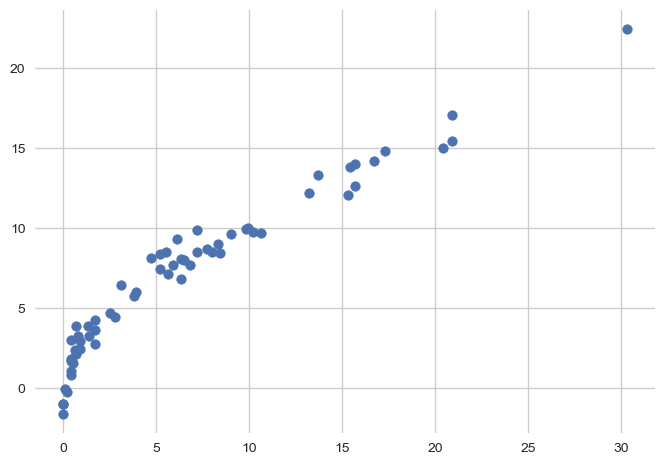

In [158]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score


elastic=ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

Note: Elastic net has parameters that can improve this model. Learn more about them

### Hyperparameter Tuning

#### Cross Validation (Lasso)

In [159]:
from sklearn.linear_model import LassoCV ## performs crossvalidation in the lasso model training
lassocv=LassoCV(cv=5) ## the default cv is 5. shift+tab to view documentation
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [160]:
## We have to view the parameters it finalized its training with.
## We can still view all the parameters it tested before arriving at the final conclusion.

print('The alpha value used:', lassocv.alpha_)

The alpha value used: 0.05725391318234408


In [161]:
print('All the alpha values tried:', lassocv.alphas_)

All the alpha values tried: [7.05853002 6.58280872 6.13914944 5.72539132 5.33951911 4.97965339
 4.64404142 4.33104857 4.03915039 3.76692517 3.51304702 3.27627941
 3.05546914 2.84954075 2.65749124 2.47838523 2.31135036 2.15557308
 2.01029467 1.87480753 1.74845178 1.63061198 1.52071419 1.41822315
 1.32263965 1.23349817 1.15036452 1.0728338  1.00052839 0.93309613
 0.87020857 0.81155943 0.75686304 0.705853   0.65828087 0.61391494
 0.57253913 0.53395191 0.49796534 0.46440414 0.43310486 0.40391504
 0.37669252 0.3513047  0.32762794 0.30554691 0.28495408 0.26574912
 0.24783852 0.23113504 0.21555731 0.20102947 0.18748075 0.17484518
 0.1630612  0.15207142 0.14182231 0.13226397 0.12334982 0.11503645
 0.10728338 0.10005284 0.09330961 0.08702086 0.08115594 0.0756863
 0.0705853  0.06582809 0.06139149 0.05725391 0.05339519 0.04979653
 0.04644041 0.04331049 0.0403915  0.03766925 0.03513047 0.03276279
 0.03055469 0.02849541 0.02657491 0.02478385 0.0231135  0.02155573
 0.02010295 0.01874808 0.01748452 0

In [162]:
print('Print the MSE path. Remember it has about 100 iteration with cv of 5. So we should have 500 MSElassocv', lassocv.mse_path_)

Print the MSE path. Remember it has about 100 iteration with cv of 5. So we should have 500 MSElassocv [[53.64536329 65.39074075 54.89628985 77.90299066 39.38236846]
 [46.99139716 59.81506814 49.29840831 75.6645852  35.31758355]
 [41.14908917 53.9178721  42.49594889 68.35708298 31.76996123]
 [36.05788169 48.41773965 36.66879347 61.92819453 28.67296816]
 [31.62067285 42.76466229 31.68391904 56.26841266 24.93183295]
 [27.75285367 37.81922812 27.42599138 51.28216115 21.56888645]
 [24.3807738  33.49107651 23.7950306  45.25481907 18.66094162]
 [21.44052804 29.70161639 20.70460191 39.90418045 16.14837778]
 [18.876308   26.38208059 18.07969934 35.23429953 13.97821475]
 [16.63960395 23.47341883 15.85530749 31.15712074 12.10483403]
 [14.68819307 20.92329068 13.97555108 27.59649208 10.48862803]
 [12.98525144 18.68636627 12.39173305 24.48611006  9.09521221]
 [11.49893734 16.72312788 11.06186319 21.7677198   7.89445038]
 [10.2013182  14.9991189   9.94965275 19.39216316  6.86106557]
 [ 9.06814642 1

Mean absolute error:  0.6199701158263431
R2 score:  0.9820946715928275


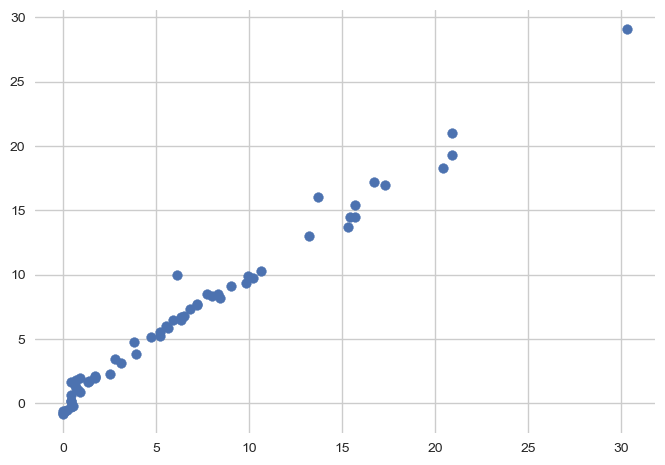

In [163]:
y_pred=lassocv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

The accuracy is very good. We have a very strong model

#### Cross Validation (Ridge)

Mean absolute error:  0.5642305340105693
R2 score:  0.9842993364555513


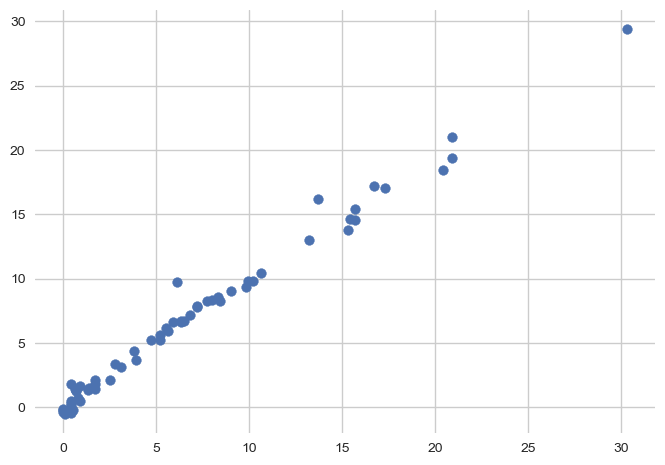

In [164]:
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV(cv=5)
## if you read the documentation you will find out that if you leave out the cv parameter it if use Leave-One-Out cross validation
ridgecv.fit(X_train_scaled, y_train)
y_pred=ridgecv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

In [165]:
## In order to view the entire parameters used
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

Mean absolute error:  0.5642305340105693
R2 score:  0.9842993364555513


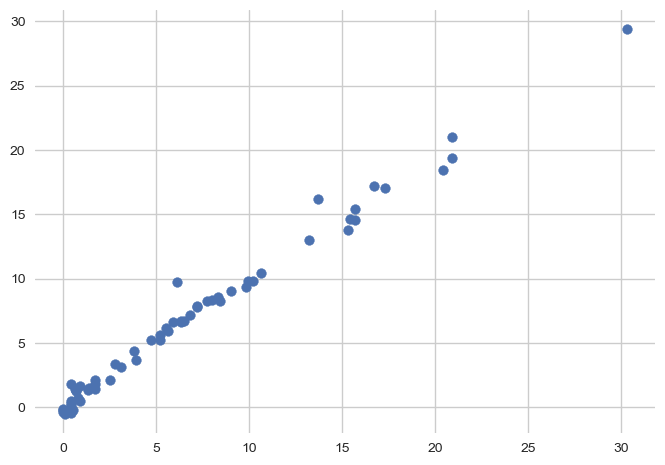

In [166]:
#### Cross-Validation (ElasticNet) 
from sklearn.linear_model import ElasticNetCV

elasticnetcv = RidgeCV(cv=5)

elasticnetcv.fit(X_train_scaled, y_train)
y_pred=elasticnetcv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print('R2 score: ', score)
plt.scatter(y_test,y_pred)

#### PLEASE LEARN THE PARMETERS USED ON YOUR OWN

## Deployment

ridge is the best performing model. We will use **PICKLE** to store the model

In [167]:
scaler

StandardScaler()

In [168]:
ridge

Ridge()

In [172]:
## Pickle the models
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))

In [173]:
## load the model and predict
ridge_model = pickle.load(open('ridge.pkl','rb'))
ridge_pred=ridge_model.predict(X_test_scaled)
ridge_pred

array([ 8.23695957,  7.77133489, -0.20576373,  4.38641746,  6.73014882,
        1.38083778,  2.09821574,  7.89573609,  1.68710448,  3.39608166,
        0.45955107,  9.77115691,  9.35289622, 17.03184252, 18.46891974,
        1.31920963,  1.83197436, -0.12967473,  7.18616187,  3.15029834,
        1.4415705 ,  0.20532056,  6.60901914,  0.34619299, 20.97777968,
        5.22692975,  5.97066219,  9.82599838, -0.18171193,  9.83698303,
        6.65050786, -0.43256887, 10.40995342, 14.57517502,  1.52182034,
        0.47799404,  2.09598786,  6.18530003, -0.51720703, -0.27108924,
        6.74656177,  1.8115675 ,  8.60302337, -0.34697492, 15.41467762,
        8.34164636,  8.27783782,  1.41852757, 12.97837116,  1.24905696,
       29.40913561,  5.66093325, 17.23898525, 19.38721803, 13.82278407,
       16.19164908,  0.70419803,  9.05107798,  3.6760472 , 14.63186999,
        5.27050843])

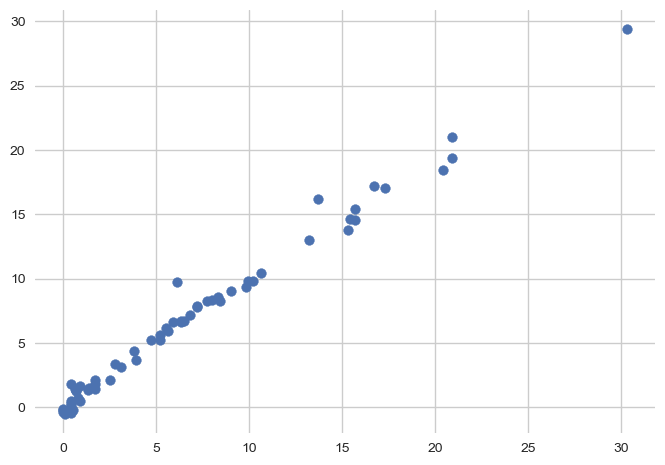

In [174]:
plt.scatter(y_test,ridge_pred)